<a href="https://colab.research.google.com/github/sruthi-analyst/sruthi-codeboosters-2026/blob/main/Day3/Day_3_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
API_KEY = '84f9cb655f58c2e1901feba8466c1384'
BASE_URL = 'https://api.openweathermap.org/data/2.5/weather?'
CITIES = ['Coimbatore', 'Delhi', 'Chennai', 'Jolarpet', 'Pollachi',
          'Tirunelveli', 'Jaipur', 'Kolkata', 'Pune', 'Bangalore']

print(f'API configured for {len(CITIES)} cities')
print(f'Cities: {CITIES}')

API configured for 10 cities
Cities: ['Coimbatore', 'Delhi', 'Chennai', 'Jolarpet', 'Pollachi', 'Tirunelveli', 'Jaipur', 'Kolkata', 'Pune', 'Bangalore']


In [26]:
import requests

def fetch_weather(city, api_key):
  """
  Fetch current weather data for a given city.
  Returns a dictionary with weather metrices, or None on failure.
  """
  params = {
      'q': city,            # City name query parameter
      'appid': api_key,     # Authentication key
      'units': 'metric'     # Returns temperature in Celcius
  }
  # params in a dictionary - requests will encode it into the URL: ?q=Mumbai&appid=KEY&units=metric

  try:
    response = requests.get(BASE_URL, params = params, timeout=10)
    #requests.get() sends an HTTP GET request to BASE URL
    #timeout=10 waits max for 10 seconds; raise error if no response

    if response.status_code==200:
      #statuc_code 200 = HTTP OK = request was successful
      data = response.json()
      # .json parses the JSON text body into a Python dictionary

      return{
          'city': city,
          'temperature' : round(data['main']['temp'], 1),
          'feels_like' : round(data['main']['feels_like'], 1),
          'humidity' : data['main']['humidity'],
          'pressure' : data['main']['pressure'],
          'wind_speed' : data['wind']['speed'],
          'condition' : data['weather'][0]['description'].title(),
          'visibility' : data.get('visibility', 0) #.get('visibility', 0) is safe access: return 0 if key is missing,
          #1000 - convert meters to kilimeters (integer division)
      }
    else:
      print(f' ERROR {response.status_code} for {city}: {response.json().get('message', 'Unknown Error')}')
      return None
  except requests.exceptions.ConnectionError:
    print(f'CONNECTION ERROR for {city} - check internet connection')
    return None

  except requests.exceptions.Timeout:
    print(f'TIMEOUT ERROR for {city} - API did not respond in 10 seconds')
    return None

print("Calling Weathe API...")
weather_records=[]

for city in CITIES:
  print(f' Fetching: {city}...', end='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f'{record['temperature']}°C', {record['condition']})
    print('\n', record)
  else:
    print('FAILED')
print(f'\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities')

Calling Weathe API...
 Fetching: Coimbatore...33.9°C {'Scattered Clouds'}

 {'city': 'Coimbatore', 'temperature': 33.9, 'feels_like': 38.8, 'humidity': 52, 'pressure': 1008, 'wind_speed': 4.12, 'condition': 'Scattered Clouds', 'visibility': 7000}
 Fetching: Delhi...44.0°C {'Clear Sky'}

 {'city': 'Delhi', 'temperature': 44.0, 'feels_like': 41.1, 'humidity': 10, 'pressure': 999, 'wind_speed': 5.14, 'condition': 'Clear Sky', 'visibility': 7000}
 Fetching: Chennai...35.8°C {'Few Clouds'}

 {'city': 'Chennai', 'temperature': 35.8, 'feels_like': 42.8, 'humidity': 53, 'pressure': 1005, 'wind_speed': 5.14, 'condition': 'Few Clouds', 'visibility': 6000}
 Fetching: Jolarpet...35.8°C {'Broken Clouds'}

 {'city': 'Jolarpet', 'temperature': 35.8, 'feels_like': 38.1, 'humidity': 38, 'pressure': 1006, 'wind_speed': 1.86, 'condition': 'Broken Clouds', 'visibility': 10000}
 Fetching: Pollachi...33.8°C {'Overcast Clouds'}

 {'city': 'Pollachi', 'temperature': 33.8, 'feels_like': 37.0, 'humidity': 47, '

In [27]:
import requests

In [37]:
def fetch_weather(city, api_key):
  params = {'q': city, 'appid': api_key, 'units': 'metric'}
  try:
    response = requests.get(BASE_URL, params = params, timeout=10)
    if response.status_code==200:
      data = response.json()
      return{
          'CITY': city,
          'Temperature' : round(data['main']['temp'], 1),
          'Feels_like' : round(data['main']['feels_like'], 1),
          'Humidity' : data['main']['humidity'],
          'Pressure' : data['main']['pressure'],
          'Wind_speed' : data['wind']['speed'],
          'Condition' : data['weather'][0]['description'].title(),
          'Visibility' : data.get('visibility', 0)
      }
    else:
      print(f' ERROR {response.status_code} for {city}: {response.json().get('message', 'Unknown Error')}')
      return None
  except requests.exceptions.Timeout:
      print(f'TIMEOUT ERROR for {city} - API did not respond in 10 seconds')
      return None
print("Calling Weathe API...")
weather_records=[]

for city in CITIES:
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
  else:
    print("Failed")
print(f'\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities')

Calling Weathe API...

Successfully fetched: 10/10 cities


In [38]:
for res in weather_records:
  for r in res:
    print(r, ":", res[r])
  print("\n")

CITY : Coimbatore
Temperature : 33.9
Feels_like : 38.8
Humidity : 52
Pressure : 1008
Wind_speed : 4.12
Condition : Scattered Clouds
Visibility : 7000


CITY : Delhi
Temperature : 44.0
Feels_like : 41.1
Humidity : 10
Pressure : 999
Wind_speed : 5.14
Condition : Clear Sky
Visibility : 7000


CITY : Chennai
Temperature : 35.9
Feels_like : 42.9
Humidity : 53
Pressure : 1005
Wind_speed : 5.14
Condition : Few Clouds
Visibility : 6000


CITY : Jolarpet
Temperature : 35.5
Feels_like : 38.8
Humidity : 42
Pressure : 1007
Wind_speed : 1.86
Condition : Broken Clouds
Visibility : 10000


CITY : Pollachi
Temperature : 33.8
Feels_like : 37.0
Humidity : 47
Pressure : 1008
Wind_speed : 8.11
Condition : Overcast Clouds
Visibility : 10000


CITY : Tirunelveli
Temperature : 38.3
Feels_like : 41.4
Humidity : 34
Pressure : 1006
Wind_speed : 6.61
Condition : Broken Clouds
Visibility : 10000


CITY : Jaipur
Temperature : 42.6
Feels_like : 41.3
Humidity : 15
Pressure : 1001
Wind_speed : 5.14
Condition : Haze
V

In [51]:
import pandas as pd

weather_df = pd.DataFrame(weather_records)
print(weather_df.to_string(index=False))

print("\nShape of weather_df: ", weather_df.shape)
print(f"Missing Values : {weather_df.isnull().sum().sum()}")
print("\nData types: \n",weather_df.dtypes)

       CITY  Temperature  Feels_like  Humidity  Pressure  Wind_speed        Condition  Visibility
 Coimbatore         33.9        38.8        52      1008        4.12 Scattered Clouds        7000
      Delhi         44.0        41.1        10       999        5.14        Clear Sky        7000
    Chennai         35.9        42.9        53      1005        5.14       Few Clouds        6000
   Jolarpet         35.5        38.8        42      1007        1.86    Broken Clouds       10000
   Pollachi         33.8        37.0        47      1008        8.11  Overcast Clouds       10000
Tirunelveli         38.3        41.4        34      1006        6.61    Broken Clouds       10000
     Jaipur         42.6        41.3        15      1001        5.14             Haze        5000
    Kolkata         32.0        37.6        62      1001        4.12             Haze        5000
       Pune         36.3        35.7        26      1008        3.76  Overcast Clouds       10000
  Bangalore         

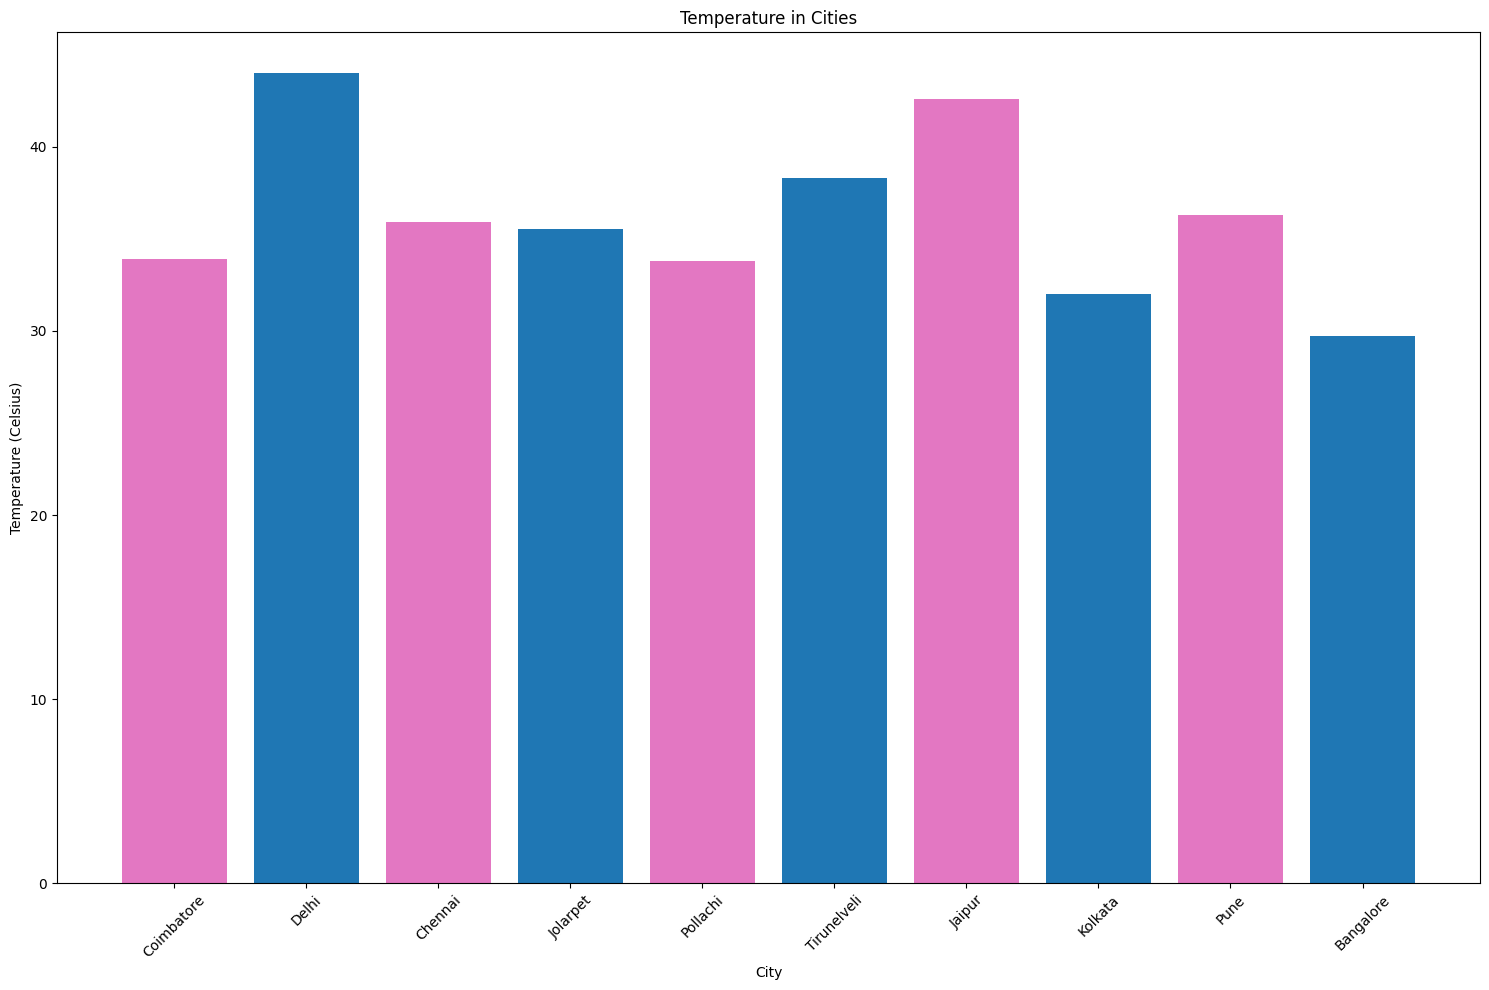

In [62]:
import matplotlib.pyplot as plt
import requests
import pandas as pd

plt.figure(figsize=(15, 10))
plt.bar(weather_df['CITY'], weather_df['Temperature'], color=['tab:pink', 'tab:blue'])
plt.xlabel('City')
plt.ylabel('Temperature (Celsius)')
plt.title('Temperature in Cities')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()